### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [2]:
data = pd.read_csv('data/coupons.csv')

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

2. Investigate the dataset for missing or problematic data.

In [4]:
# 3. Missing values - count and percentage per column
missing_count = data.isnull().sum()
missing_pct = (data.isnull().sum() / len(data) * 100).round(2)

missing_df = pd.DataFrame({
    'missing_count': missing_count,
    'missing_pct': missing_pct
})

# Show only columns that have missing values, sorted
missing_df[missing_df['missing_count'] > 0].sort_values('missing_count', ascending=False)

,missing_count,missing_pct
car,12576,99.15
CoffeeHouse,217,1.71
Restaurant20To50,189,1.49
CarryAway,151,1.19
RestaurantLessThan20,130,1.02
Bar,107,0.84


3. Decide what to do about your missing data -- drop, replace, other...

In [5]:
# Start with a copy so we preserve the original
df = data.copy()
print(f"Starting shape: {df.shape}")
# 'car' is ~99% missing
df = df.drop(columns=['car'])
# This column has only 1 unique value (always 1)
df = df.drop(columns=['toCoupon_GEQ5min'])
freq_cols = ['Bar', 'CoffeeHouse', 'CarryAway',
             'RestaurantLessThan20', 'Restaurant20To50']
# For Bar, CoffeeHouse, CarryAway, RestaurantLessThan20, Restaurant20To50 — each has <2% missing. 
df = df.dropna(subset=freq_cols)
print(f"After dropping rows with missing frequency data: {df.shape}")

Starting shape: (12684, 26)
After dropping rows with missing frequency data: (12079, 24)


4. What proportion of the total observations chose to accept the coupon?



In [6]:
# Proportion of observations that accepted the coupon
acceptance_rate = df['Y'].mean()

print(f"Total observations: {len(df)}")
print(f"Accepted (Y=1): {df['Y'].sum()}")
print(f"Rejected (Y=0): {(df['Y'] == 0).sum()}")
print(f"\nAcceptance rate: {acceptance_rate:.4f} ({acceptance_rate*100:.2f}%)")

Total observations: 12079
Accepted (Y=1): 6877
Rejected (Y=0): 5202

Acceptance rate: 0.5693 (56.93%)


5. Use a bar plot to visualize the `coupon` column.

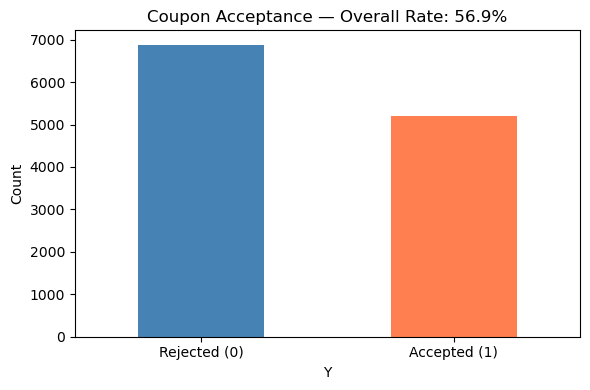

In [7]:
plt.figure(figsize=(6, 4))
df['Y'].value_counts().plot(kind='bar', color=['steelblue', 'coral'])
plt.xticks([0, 1], ['Rejected (0)', 'Accepted (1)'], rotation=0)
plt.ylabel('Count')
plt.title(f'Coupon Acceptance — Overall Rate: {acceptance_rate*100:.1f}%')
plt.tight_layout()
plt.show()

6. Use a histogram to visualize the temperature column.

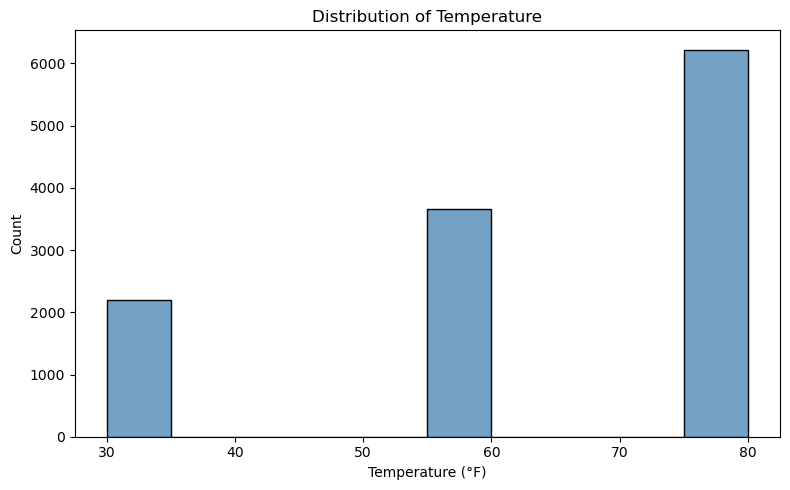

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='temperature', bins=10, color='steelblue', edgecolor='black')
plt.xlabel('Temperature (°F)')
plt.ylabel('Count')
plt.title('Distribution of Temperature')
plt.tight_layout()
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [9]:
# Create a new DataFrame with only bar coupons
bar = df[df['coupon'] == 'Bar'].copy()

print(f"Number of bar coupon observations: {len(bar)}")
print(f"\nFirst few rows:")
bar.head()

Number of bar coupon observations: 1913

First few rows:


,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,never,less1,4~8,4~8,less1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,never,less1,4~8,4~8,less1,0,0,1,0,1
39,Work,Alone,Sunny,55,7AM,Bar,1d,Male,21,Single,...,never,less1,4~8,4~8,less1,1,1,0,1,1
46,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,46,Single,...,never,4~8,1~3,1~3,never,0,0,0,1,0
57,Home,Alone,Sunny,55,6PM,Bar,1d,Male,46,Single,...,never,4~8,1~3,1~3,never,0,0,1,0,0


2. What proportion of bar coupons were accepted?


In [10]:
# Proportion of bar coupons accepted
bar_acceptance_rate = bar['Y'].mean()

print(f"Total bar coupons: {len(bar)}")
print(f"Accepted: {bar['Y'].sum()}")
print(f"Rejected: {(bar['Y'] == 0).sum()}")
print(f"\nBar coupon acceptance rate: {bar_acceptance_rate:.4f} ({bar_acceptance_rate*100:.2f}%)")

Total bar coupons: 1913
Accepted: 788
Rejected: 1125

Bar coupon acceptance rate: 0.4119 (41.19%)


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [11]:
# Group 1: went to a bar 3 or fewer times a month
# This includes: 'never', 'less1' (less than 1), and '1~3'
low_bar = bar[bar['Bar'].isin(['never', 'less1', '1~3'])]

# Group 2: went to a bar more than 3 times a month
# This includes: '4~8' and 'gt8' (greater than 8)
high_bar = bar[bar['Bar'].isin(['4~8', 'gt8'])]

low_rate = low_bar['Y'].mean()
high_rate = high_bar['Y'].mean()

print(f"Went 3 or fewer times/month: {len(low_bar)} observations")
print(f"  Acceptance rate: {low_rate:.4f} ({low_rate*100:.2f}%)")

print(f"\nWent more than 3 times/month: {len(high_bar)} observations")
print(f"  Acceptance rate: {high_rate:.4f} ({high_rate*100:.2f}%)")

print(f"\nDifference: {(high_rate - low_rate)*100:.2f} percentage points")

Went 3 or fewer times/month: 1720 observations
  Acceptance rate: 0.3727 (37.27%)

Went more than 3 times/month: 193 observations
  Acceptance rate: 0.7617 (76.17%)

Difference: 38.90 percentage points


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [12]:
# Group 1: go to a bar more than once a month AND over age 25

frequent_older = bar[
    (bar['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (~bar['age'].isin(['below21', '21']))
]

# Group 2: everyone else
all_others = bar.drop(frequent_older.index)

rate_group1 = frequent_older['Y'].mean()
rate_group2 = all_others['Y'].mean()

print(f"Group 1 - Bar >1/month AND age >25: {len(frequent_older)} observations")
print(f"  Acceptance rate: {rate_group1:.4f} ({rate_group1*100:.2f}%)")

print(f"\nGroup 2 - All others: {len(all_others)} observations")
print(f"  Acceptance rate: {rate_group2:.4f} ({rate_group2*100:.2f}%)")

print(f"\nDifference: {(rate_group1 - rate_group2)*100:.2f} percentage points")

Group 1 - Bar >1/month AND age >25: 403 observations
  Acceptance rate: 0.6898 (68.98%)

Group 2 - All others: 1510 observations
  Acceptance rate: 0.3377 (33.77%)

Difference: 35.21 percentage points


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [13]:
# Group 1: Bar >1/month AND passenger is NOT 'Kid(s)' AND occupation is NOT 'Farming Fishing & Forestry'
# Note: column name is 'passanger' (typo in dataset)

group1 = bar[
    (bar['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (bar['passanger'] != 'Kid(s)') &
    (bar['occupation'] != 'Farming Fishing & Forestry')
]

# Group 2: everyone else
group2 = bar.drop(group1.index)

rate_group1 = group1['Y'].mean()
rate_group2 = group2['Y'].mean()

print(f"Group 1 - Bar >1/mo, no kid passenger, not farming/fishing/forestry:")
print(f"  Observations: {len(group1)}")
print(f"  Acceptance rate: {rate_group1:.4f} ({rate_group1*100:.2f}%)")

print(f"\nGroup 2 - All others:")
print(f"  Observations: {len(group2)}")
print(f"  Acceptance rate: {rate_group2:.4f} ({rate_group2*100:.2f}%)")

print(f"\nDifference: {(rate_group1 - rate_group2)*100:.2f} percentage points")

Group 1 - Bar >1/mo, no kid passenger, not farming/fishing/forestry:
  Observations: 530
  Acceptance rate: 0.7094 (70.94%)

Group 2 - All others:
  Observations: 1383
  Acceptance rate: 0.2979 (29.79%)

Difference: 41.15 percentage points


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [14]:
# Condition A: Bar >1/month AND passenger != Kid(s) AND maritalStatus != Widowed
cond_A = (
    (bar['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (bar['passanger'] != 'Kid(s)') &
    (bar['maritalStatus'] != 'Widowed')
)

# Condition B: Bar >1/month AND age < 30
# Age values under 30: 'below21', '21', '26'
cond_B = (
    (bar['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (bar['age'].isin(['below21', '21', '26']))
)

# Condition C: cheap restaurants >4/month AND income < $50K
# RestaurantLessThan20 >4: '4~8', 'gt8'
# Income < $50K: 'Less than $12500', '$12500 - $24999', '$25000 - $37499', '$37500 - $49999'
low_income = ['Less than $12500', '$12500 - $24999',
              '$25000 - $37499', '$37500 - $49999']

cond_C = (
    (bar['RestaurantLessThan20'].isin(['4~8', 'gt8'])) &
    (bar['income'].isin(low_income))
)

# Combine with OR
group1 = bar[cond_A | cond_B | cond_C]
group2 = bar.drop(group1.index)

rate_group1 = group1['Y'].mean()
rate_group2 = group2['Y'].mean()

print(f"Group 1 - meets any of conditions A, B, or C:")
print(f"  Observations: {len(group1)}")
print(f"  Acceptance rate: {rate_group1:.4f} ({rate_group1*100:.2f}%)")

print(f"\nGroup 2 - meets none of the conditions:")
print(f"  Observations: {len(group2)}")
print(f"  Acceptance rate: {rate_group2:.4f} ({rate_group2*100:.2f}%)")

print(f"\nDifference: {(rate_group1 - rate_group2)*100:.2f} percentage points")

Group 1 - meets any of conditions A, B, or C:
  Observations: 746
  Acceptance rate: 0.5871 (58.71%)

Group 2 - meets none of the conditions:
  Observations: 1167
  Acceptance rate: 0.2999 (29.99%)

Difference: 28.72 percentage points


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

In [15]:
# Based on the analysis we've done, here are the hypotheses
# 1. Must-have: frequent bar visits (>1/month, ideally >3/month)
# 2. Strong filter: no kids in the car at coupon delivery time
# 3. Modest tightening: exclude widowed drivers
# 4. Weak/optional: age and income filters add noise more than signal

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [16]:
coffee = df[df['coupon'] == 'Coffee House'].copy()

print(f"Total coffee house coupon observations: {len(coffee)}")
print(f"Acceptance rate: {coffee['Y'].mean()*100:.2f}%")

Total coffee house coupon observations: 3816
Acceptance rate: 49.63%


                 mean  count  mean_pct
CoffeeHouse                           
never        0.175223    896     17.52
less1        0.480989   1052     48.10
1~3          0.647694   1019     64.77
4~8          0.682446    507     68.24
gt8          0.657895    342     65.79


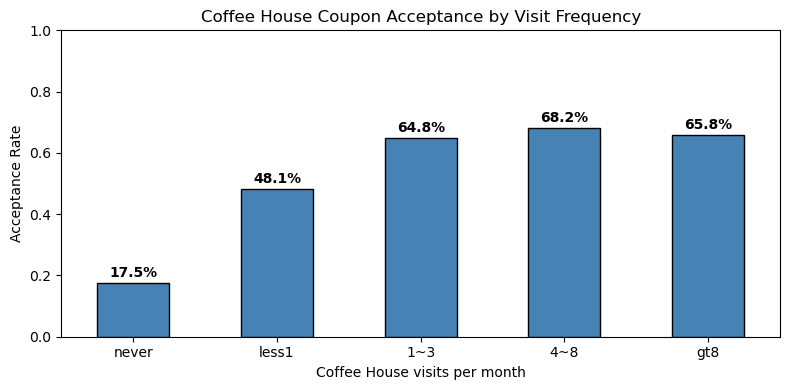

In [17]:
freq_order = ['never', 'less1', '1~3', '4~8', 'gt8']
rates_by_freq = coffee.groupby('CoffeeHouse')['Y'].agg(['mean', 'count']).reindex(freq_order)
rates_by_freq['mean_pct'] = (rates_by_freq['mean'] * 100).round(2)
print(rates_by_freq)

# Visualize
plt.figure(figsize=(8, 4))
rates_by_freq['mean'].plot(kind='bar', color='steelblue', edgecolor='black')
plt.ylabel('Acceptance Rate')
plt.xlabel('Coffee House visits per month')
plt.title('Coffee House Coupon Acceptance by Visit Frequency')
plt.xticks(rotation=0)
plt.ylim(0, 1)
for i, v in enumerate(rates_by_freq['mean']):
    plt.text(i, v + 0.02, f'{v*100:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

          mean  count  mean_pct
time                           
7AM   0.440000    875     44.00
10AM  0.634772    857     63.48
2PM   0.545455    759     54.55
6PM   0.412272   1043     41.23
10PM  0.429078    282     42.91


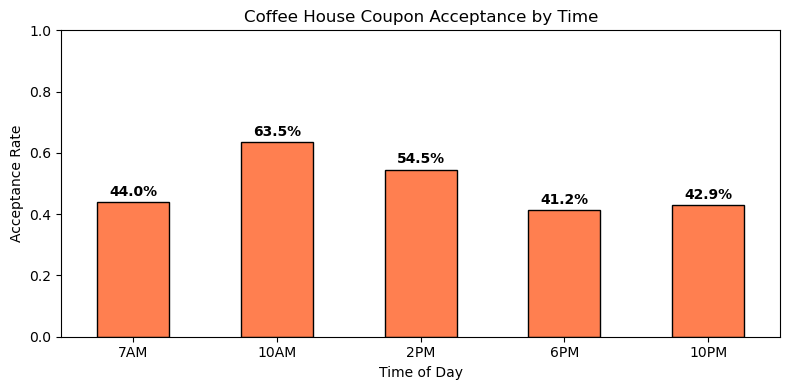

In [18]:
time_order = ['7AM', '10AM', '2PM', '6PM', '10PM']
rates_by_time = coffee.groupby('time')['Y'].agg(['mean', 'count']).reindex(time_order)
rates_by_time['mean_pct'] = (rates_by_time['mean'] * 100).round(2)
print(rates_by_time)

plt.figure(figsize=(8, 4))
rates_by_time['mean'].plot(kind='bar', color='coral', edgecolor='black')
plt.ylabel('Acceptance Rate')
plt.xlabel('Time of Day')
plt.title('Coffee House Coupon Acceptance by Time')
plt.xticks(rotation=0)
plt.ylim(0, 1)
for i, v in enumerate(rates_by_time['mean']):
    plt.text(i, v + 0.02, f'{v*100:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
rates_by_dest = coffee.groupby('destination')['Y'].agg(['mean', 'count']).sort_values('mean', ascending=False)
rates_by_dest['mean_pct'] = (rates_by_dest['mean'] * 100).round(2)
print(rates_by_dest)

                     mean  count  mean_pct
destination                               
No Urgent Place  0.578178   2053     57.82
Work             0.440000    875     44.00
Home             0.362613    888     36.26


In [20]:
# Hypothesis: frequent coffee-house goers, NOT driving home, with a longer expiration window
target = coffee[
    (coffee['CoffeeHouse'].isin(['1~3', '4~8', 'gt8'])) &
    (coffee['destination'] != 'Home') &
    (coffee['expiration'] == '1d')
]
others = coffee.drop(target.index)

print(f"Target group: {len(target)} obs, acceptance = {target['Y'].mean()*100:.2f}%")
print(f"Others: {len(others)} obs, acceptance = {others['Y'].mean()*100:.2f}%")
print(f"Difference: {(target['Y'].mean() - others['Y'].mean())*100:.2f} pp")

Target group: 614 obs, acceptance = 80.29%
Others: 3202 obs, acceptance = 43.75%
Difference: 36.54 pp
